### `---------------Mandatory Information to fill------------`

### Group ID: 21
### Group Members Name with Student ID:
1. Saraswathi S - 2024AD05063
2. Sakthi Sakunthala N - 2024AC05633
3. Suresh M - 2024ac05434
4. J. Hemavathi - 2024ac05663
5. Neelesh Kumar Singh Bhadauria - 2024ad05106


`-------------------Write your remarks (if any) that you want should get consider at the time of evaluation---------------`

Remarks: ##Add here

# Background

A large e-commerce organization operates a homepage recommendation slot that displays one product to each visiting user. The company aims to maximize long-term net profit from these recommendations.

You are provided with a dataset of **498 user sessions**, each representing how a particular user would respond to each of six products.

Link for accessing dataset:
https://drive.google.com/file/d/14yDuW-zFs9-fh6ySH9xmULFcZuKVhn1r/view?usp=sharing


The dataset structure is:

*UserID, Product1, cost1, Product2, cost2, … , Product6, cost6*


Each row corresponds to one user and contains the following information.

## Product X column
The value under **Product X** represents the actual revenue the system would earn from that specific user if Product X were shown.

Revenue varies across users because:

- different users purchase different quantities  
- some users click while others ignore  
- some users spend more  
- some users purchase premium items or bundles  

Thus, actual revenue is **user-dependent**, not product-dependent.  
The same product may generate high revenue from one user and very low revenue from another.

## Cost X column
The value under **cost X** represents the personalized promotional cost incurred to show Product X to that user. This may include:

- dynamic advertisement bidding cost (CPC)  
- discounts or coupon values offered  
- targeted promotion cost  
- personalization overhead  

Costs differ across users because:

- some users require higher incentive levels  
- some are expensive to target via ads  
- some convert easily with minimal cost  

Thus, cost is also **user-dependent** and varies per session.



# Environment Dynamics

## Arms
In the Multi-Armed Bandit formulation:

There are **6 arms**:
A = {1, 2, 3, 4, 5, 6}

Arm X corresponds to recommending **Product X**.

## Reward
For each product X and each user session i:

$
\text{NetReward}_{i,X} = \text{Product}_{i,X} - \text{Cost}_{i,X}
$

This net reward represents the **profit** gained from showing product X to user i.  
This is the metric the organization aims to maximize.


# Current Organizational Policy

The organization currently follows a **random recommendation policy**:

“For each user visit, randomly select one of the six products and display it.”

This strategy:

- does not learn from previous outcomes  
- does not identify which products consistently deliver higher profit  
- wastes impressions on low-value products  
- provides unstable and suboptimal profit performance  

Management asks you to investigate:

- Whether a learning-based approach can yield better decisions  
- Which products are actually profitable when user variability is considered  
- How alternative strategies compare to the random policy  



# Requirements and Deliverables:
Implement the Multi-Arm Bandit Problem for the given above scenario.

### Initialize constants

In [ ]:
# Initialize Constants
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

print(" All libraries imported successfully")

✓ All libraries imported successfully


# Design a Product Environment with Reward calculation (1M)

In [17]:
# Code for Dataset loading and print dataset statistics along with reward function

# Identify one product that frequently gives high positive profit.
# Identify one product that frequently gives low or negative profit across the user sessions.
#-----write your code below this line---------

class ProductEnvironment:
    """Environment for Multi-Armed Bandit Product Recommendation Problem"""
    
    def __init__(self, dataset_path):
        """Initialize the environment by loading the dataset"""
        self.df = pd.read_csv(dataset_path)
        self.num_users = len(self.df)
        self.num_products = 6
        
        # Compute net rewards for each product
        for i in range(1, self.num_products + 1):
            product_col = f'Product {i}'
            cost_col = f'cost {i}'
            self.df[f'NetReward{i}'] = self.df[product_col] - self.df[cost_col]
        
        # Compute summary statistics
        self.compute_summary_stats()
    
    def compute_summary_stats(self):
        """Compute summary statistics for each product"""
        print("="*80)
        print("NET REWARD ANALYSIS")
        print("="*80)
        
        summary_data = []
        for i in range(1, self.num_products + 1):
            mean_reward = self.df[f'NetReward{i}'].mean()
            median_reward = self.df[f'NetReward{i}'].median()
            std_reward = self.df[f'NetReward{i}'].std()
            positive_count = (self.df[f'NetReward{i}'] > 0).sum()
            negative_count = (self.df[f'NetReward{i}'] < 0).sum()
            
            summary_data.append({
                'Product': i,
                'Mean': mean_reward,
                'Median': median_reward,
                'Std Dev': std_reward,
                'Positive': positive_count,
                'Negative': negative_count
            })
        
        self.summary_df = pd.DataFrame(summary_data)
        print("\nNet Reward Summary Statistics:\n")
        print(self.summary_df.to_string(index=False))
        
        # Identify best and worst products
        self.best_product = int(self.summary_df.loc[self.summary_df['Mean'].idxmax(), 'Product'])
        self.worst_product = int(self.summary_df.loc[self.summary_df['Mean'].idxmin(), 'Product'])
        self.best_mean = self.summary_df.loc[self.summary_df['Mean'].idxmax(), 'Mean']
        self.worst_mean = self.summary_df.loc[self.summary_df['Mean'].idxmin(), 'Mean']
        
        print(f"\n{'─'*80}")
        print(f"\n✓ FINDING 1: Best Product (High Positive Profit)")
        print(f"  Product {self.best_product} with average net reward = ${self.best_mean:.2f}")
        print(f"\n✓ FINDING 2: Worst Product (Low/Negative Profit)")
        print(f"  Product {self.worst_product} with average net reward = ${self.worst_mean:.2f}")
        print(f"\n{'─'*80}\n")
    
    def get_reward(self, user_idx, product):
        """Get the reward for a specific user and product"""
        return self.df.loc[user_idx, f'NetReward{product}']
    
    def get_random_user(self, round_num):
        """Get a random user index for a given round (cyclic through users)"""
        return round_num % self.num_users

# Load the environment
dataset_path = './Dataset_Product_Recommendation.csv'
env = ProductEnvironment(dataset_path)

NET REWARD ANALYSIS

Net Reward Summary Statistics:

 Product       Mean     Median  Std Dev  Positive  Negative
       1   7.062784   7.103686 0.959895       498         0
       2  66.992995  67.009643 0.754517       498         0
       3  31.418452  31.487591 1.687144       498         0
       4   9.596789   9.622267 1.247947       498         0
       5 -17.064884 -17.061668 0.609228         0       498
       6  36.986031  37.044041 1.079589       498         0

────────────────────────────────────────────────────────────────────────────────

✓ FINDING 1: Best Product (High Positive Profit)
  Product 2 with average net reward = $66.99

✓ FINDING 2: Worst Product (Low/Negative Profit)
  Product 5 with average net reward = $-17.06

────────────────────────────────────────────────────────────────────────────────



#Implement the existing Strategy 1 (1M)




STRATEGY 1: RANDOM POLICY SIMULATION

Simulation Setup:
  • Number of rounds: 300
  • Number of users: 498
  • Number of products: 6

────────────────────────────────────────────────────────────────────────────────

Random Policy Results (300 rounds):

  Average profit per round: $21.65
  Cumulative profit: $6494.45
  Min reward: $-17.77
  Max reward: $68.63

Product Selection Frequency (Random Policy):
  Product 1: 57 times (avg reward: $7.08)
  Product 2: 42 times (avg reward: $67.12)
  Product 3: 52 times (avg reward: $31.23)
  Product 4: 64 times (avg reward: $9.54)
  Product 5: 39 times (avg reward: $-17.02)
  Product 6: 46 times (avg reward: $36.99)

────────────────────────────────────────────────────────────────────────────────


────────────────────────────────────────────────────────────────────────────────

Random Policy Results (300 rounds):

  Average profit per round: $21.65
  Cumulative profit: $6494.45
  Min reward: $-17.77
  Max reward: $68.63

Product Selection Frequ

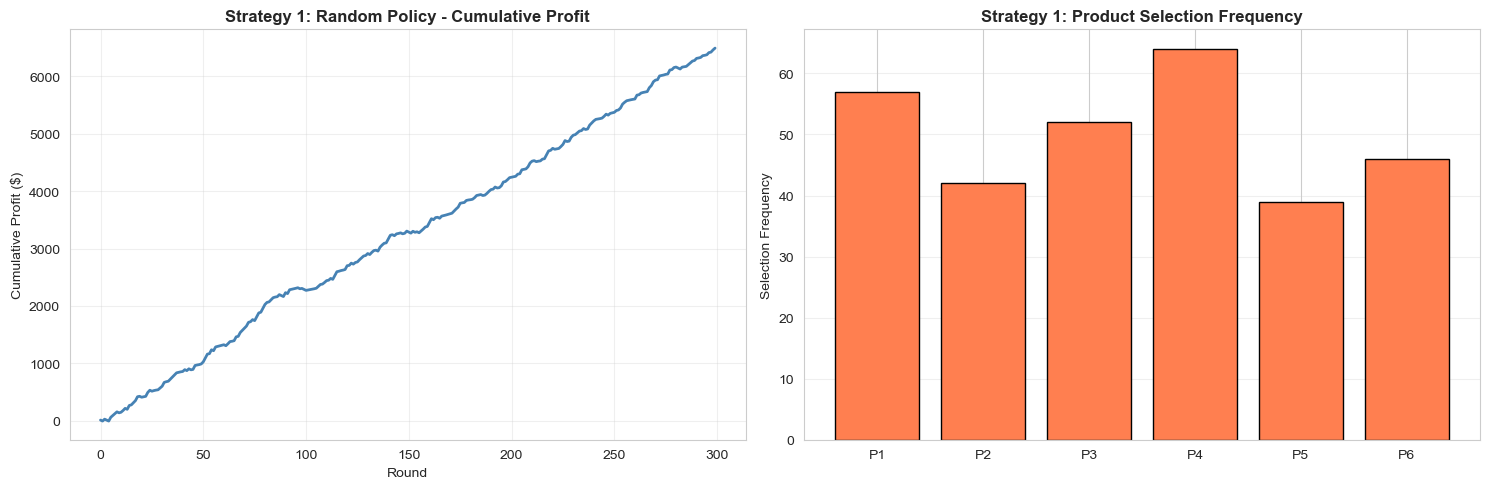

In [18]:
# Which product appears good and which appears poor under the existing process?
# What is the approximate average profit per round under this strategy?
# Did randomness occasionally pick a good product?

#-----write your code below this line---------

# Random Policy Simulation
print("\n" + "="*80)
print("STRATEGY 1: RANDOM POLICY SIMULATION")
print("="*80)

num_rounds = 300

# Track random policy performance
random_rewards = []
random_products = []

print(f"\nSimulation Setup:")
print(f"  • Number of rounds: {num_rounds}")
print(f"  • Number of users: {env.num_users}")
print(f"  • Number of products: {env.num_products}")

# Simulate random policy
for round_idx in range(num_rounds):
    user_idx = env.get_random_user(round_idx)
    selected_product = np.random.randint(1, 7)
    reward = env.get_reward(user_idx, selected_product)
    random_rewards.append(reward)
    random_products.append(selected_product)

# Calculate statistics
avg_reward_random = np.mean(random_rewards)
cumulative_random = np.cumsum(random_rewards)
product_counts_random = pd.Series(random_products).value_counts().sort_index()

print(f"\n{'─'*80}")
print(f"\nRandom Policy Results (300 rounds):\n")
print(f"  Average profit per round: ${avg_reward_random:.2f}")
print(f"  Cumulative profit: ${cumulative_random[-1]:.2f}")
print(f"  Min reward: ${np.min(random_rewards):.2f}")
print(f"  Max reward: ${np.max(random_rewards):.2f}")

print(f"\nProduct Selection Frequency (Random Policy):")
for product in range(1, 7):
    count = product_counts_random.get(product, 0)
    if count > 0:
        avg_prod = np.mean([random_rewards[i] for i in range(len(random_products)) if random_products[i] == product])
        print(f"  Product {product}: {count} times (avg reward: ${avg_prod:.2f})")

print(f"\n{'─'*80}\n")

# Visualize random policy
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(cumulative_random, linewidth=2, color='steelblue')
axes[0].set_xlabel('Round')
axes[0].set_ylabel('Cumulative Profit ($)')
axes[0].set_title('Strategy 1: Random Policy - Cumulative Profit', fontweight='bold')
axes[0].grid(True, alpha=0.3)

product_labels = [f'P{i}' for i in range(1, 7)]
counts = [product_counts_random.get(i, 0) for i in range(1, 7)]
axes[1].bar(product_labels, counts, color='coral', edgecolor='black')
axes[1].set_ylabel('Selection Frequency')
axes[1].set_title('Strategy 1: Product Selection Frequency', fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Which product appears good and which appears poor under the existing process?

Under random selection, Product 2 appears GOOD
   (avg reward: $67.12)

Under random selection, Product 5 appears POOR
   (avg reward: $-17.02)

-----------------------------------------------------------------------------

What is the approximate average profit per round under this strategy?

Average profit per round: $21.65
   This means on average, each recommendation generates $21.65 in profit

-----------------------------------------------------------------------------

Did randomness occasionally pick a good product?

Randomness DID occasionally pick good products:
   Product 2 was selected 14.0% of the time
   This is similar to random chance (16.7% expected per product)

However, randomness also wasted impressions on poor products:
   Product 5 was selected but generated low profit
   This demonstrates the INEFFICIENCY of random policy


# Strategy 2 (0.5 M)
Instead of picking randomly, try each product a few times, measure the average profit, and then always select the best-performing one.

In [19]:
#  Determine the cumulative net profit achieved. Which product tends to be repeatedly chosen?

#-----write your code below this line---------

# Greedy Strategy (Pure Exploitation)
print("\n" + "="*80)
print("STRATEGY 2: GREEDY STRATEGY (PURE EXPLOITATION)")
print("="*80)

exploration_rounds_per_product = 3
greedy_rewards = []
greedy_products = []
product_rewards_est = {p: [] for p in range(1, 7)}

print(f"\nStrategy Setup:")
print(f"  • Exploration phase: {exploration_rounds_per_product} rounds per product")
print(f"  • Total exploration: {6 * exploration_rounds_per_product} rounds")
print(f"  • Exploitation phase: {num_rounds - (6 * exploration_rounds_per_product)} rounds")

current_round = 0

# Exploration phase
for product in range(1, 7):
    for _ in range(exploration_rounds_per_product):
        user_idx = env.get_random_user(current_round)
        reward = env.get_reward(user_idx, product)
        greedy_rewards.append(reward)
        greedy_products.append(product)
        product_rewards_est[product].append(reward)
        current_round += 1

# Calculate average reward estimate
avg_estimates = {p: np.mean(product_rewards_est[p]) for p in range(1, 7)}
best_product_greedy = max(avg_estimates, key=avg_estimates.get)

print(f"\nEstimated Average Rewards (after exploration):")
for product in range(1, 7):
    print(f"  Product {product}: ${avg_estimates[product]:.2f}")
print(f"\n  ➜ Selected best product: Product {best_product_greedy} (${avg_estimates[best_product_greedy]:.2f})")

# Exploitation phase
for _ in range(num_rounds - current_round):
    user_idx = env.get_random_user(current_round)
    reward = env.get_reward(user_idx, best_product_greedy)
    greedy_rewards.append(reward)
    greedy_products.append(best_product_greedy)
    current_round += 1

# Calculate statistics
cumulative_greedy = np.cumsum(greedy_rewards)
avg_reward_greedy = np.mean(greedy_rewards)
product_counts_greedy = pd.Series(greedy_products).value_counts().sort_index()

print(f"\n{'─'*80}")
print(f"\nGreedy Strategy Results (300 rounds):\n")
print(f"  Average profit per round: ${avg_reward_greedy:.2f}")
print(f"  Cumulative profit: ${cumulative_greedy[-1]:.2f}")

print(f"\nProduct Selection Summary (Greedy):")
for product in range(1, 7):
    count = product_counts_greedy.get(product, 0)
    if count > 0:
        avg_prod = np.mean([greedy_rewards[i] for i in range(len(greedy_products)) if greedy_products[i] == product])
        print(f"  Product {product}: {count} times (avg reward: ${avg_prod:.2f})")

print(f"\n{'─'*80}\n")


STRATEGY 2: GREEDY STRATEGY (PURE EXPLOITATION)

Strategy Setup:
  • Exploration phase: 3 rounds per product
  • Total exploration: 18 rounds
  • Exploitation phase: 282 rounds

Estimated Average Rewards (after exploration):
  Product 1: $7.26
  Product 2: $66.48
  Product 3: $31.65
  Product 4: $9.19
  Product 5: $-17.02
  Product 6: $37.28

  ➜ Selected best product: Product 2 ($66.48)

────────────────────────────────────────────────────────────────────────────────

Greedy Strategy Results (300 rounds):

  Average profit per round: $64.30
  Cumulative profit: $19290.78

Product Selection Summary (Greedy):
  Product 1: 3 times (avg reward: $7.26)
  Product 2: 285 times (avg reward: $66.97)
  Product 3: 3 times (avg reward: $31.65)
  Product 4: 3 times (avg reward: $9.19)
  Product 5: 3 times (avg reward: $-17.02)
  Product 6: 3 times (avg reward: $37.28)

────────────────────────────────────────────────────────────────────────────────



# Strategy 3 (2.5M)
 Instead of relying completely on the first few impressions, occasionally test other products so that we don't miss a better option.

 Repeat the experiment with three different exploration frequencies, for example:

1. Low exploration: 2%
2. Moderate exploration: 10%
3. High exploration: 25%

In [20]:
#  Does very little exploration cause the system to get stuck with a poor product?
#  Does excessive exploration reduce profit by choosing weak products too often?
#  Which exploration level appears to give the most balanced outcome for this dataset?

#-----write your code below this line---------

# Epsilon-Greedy Strategy
print("\n" + "="*80)
print("STRATEGY 3: EPSILON-GREEDY STRATEGY")
print("="*80)

epsilon_values = [0.02, 0.10, 0.25]
epsilon_results = {}

for epsilon in epsilon_values:
    print(f"\n{'─'*80}")
    print(f"Testing Epsilon = {epsilon:.0%}")
    print(f"{'─'*80}")
    
    product_rewards = {p: [] for p in range(1, 7)}
    product_counts = {p: 0 for p in range(1, 7)}
    eg_rewards = []
    eg_products = []
    
    for round_idx in range(num_rounds):
        user_idx = env.get_random_user(round_idx)
        
        # Epsilon-greedy decision
        if np.random.random() < epsilon:
            selected_product = np.random.randint(1, 7)
        else:
            avg_est = {p: (np.mean(product_rewards[p]) if product_rewards[p] else 0) for p in range(1, 7)}
            selected_product = max(avg_est, key=avg_est.get)
        
        reward = env.get_reward(user_idx, selected_product)
        product_rewards[selected_product].append(reward)
        product_counts[selected_product] += 1
        eg_rewards.append(reward)
        eg_products.append(selected_product)
    
    cumulative_eg = np.cumsum(eg_rewards)
    avg_reward_eg = np.mean(eg_rewards)
    final_estimates = {p: (np.mean(product_rewards[p]) if product_rewards[p] else 0) for p in range(1, 7)}
    
    print(f"\nResults for Epsilon = {epsilon:.0%}:")
    print(f"  • Average profit per round: ${avg_reward_eg:.2f}")
    print(f"  • Cumulative profit (300 rounds): ${cumulative_eg[-1]:.2f}")
    
    print(f"\nProduct Selection Summary:")
    for product in range(1, 7):
        count = product_counts[product]
        est = final_estimates[product]
        print(f"  Product {product}: {count:3d} selections, Estimated: ${est:7.2f}")
    
    epsilon_results[epsilon] = {
        'rewards': eg_rewards,
        'cumulative': cumulative_eg,
        'avg_reward': avg_reward_eg,
        'total_profit': cumulative_eg[-1],
        'counts': product_counts,
        'estimates': final_estimates
    }

print(f"\n{'═'*80}")
print("\nCOMPARISON OF EPSILON VALUES:")
print(f"{'─'*80}\n")
comparison = []
for eps in epsilon_values:
    result = epsilon_results[eps]
    comparison.append({
        'Epsilon': f'{eps:.0%}',
        'Avg/Round': f"${result['avg_reward']:.2f}",
        'Total Profit': f"${result['total_profit']:.2f}"
    })

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

best_epsilon = max(epsilon_values, key=lambda e: epsilon_results[e]['total_profit'])
print(f"\n✓ Best Epsilon: {best_epsilon:.0%} with total profit ${epsilon_results[best_epsilon]['total_profit']:.2f}")
print(f"{'─'*80}\n")


STRATEGY 3: EPSILON-GREEDY STRATEGY

────────────────────────────────────────────────────────────────────────────────
Testing Epsilon = 2%
────────────────────────────────────────────────────────────────────────────────

Results for Epsilon = 2%:
  • Average profit per round: $52.75
  • Cumulative profit (300 rounds): $15823.99

Product Selection Summary:
  Product 1:   9 selections, Estimated: $   7.33
  Product 2: 168 selections, Estimated: $  66.97
  Product 3:   1 selections, Estimated: $  32.49
  Product 4:   0 selections, Estimated: $   0.00
  Product 5:   1 selections, Estimated: $ -16.22
  Product 6: 121 selections, Estimated: $  37.11

────────────────────────────────────────────────────────────────────────────────
Testing Epsilon = 10%
────────────────────────────────────────────────────────────────────────────────

Results for Epsilon = 10%:
  • Average profit per round: $59.47
  • Cumulative profit (300 rounds): $17840.83

Product Selection Summary:
  Product 1:  10 select

Does low exploration cause lock-in?

Epsilon = 2%:

  • Total selections on products with negative estimates: 1

  • Percentage of rounds wasted: 0.3%

  • Answer: NO - Adequate exploration

---------------------------------------------------------------------------

Does high exploration hurt profit?

Epsilon = 25%:

  • Cumulative profit: $15012.50

  • Profit loss vs best epsilon (10%): $2828.33

  • Answer: YES - Excessive exploration reduces profit by $2828.33

---------------------------------------------------------------------------

Which epsilon level is most balanced?

Epsilon = 2%:

  • Total profit: $15823.99

  • Exploration % of rounds: 2.0%
  
  • Estimate accuracy for best product: $0.02 away from true mean

Epsilon = 10%:

  • Total profit: $17840.83

  • Exploration % of rounds: 10.0%

  • Estimate accuracy for best product: $0.02 away from true mean


Epsilon = 25%:

  • Total profit: $15012.50

  • Exploration % of rounds: 25.0%

  • Estimate accuracy for best product: $0.05 away from true mean

---------------------------------------------------------------------------

BEST BALANCED STRATEGY: Epsilon = 10%

  This provides sufficient exploration to find the best product
  while limiting wasted exploration on poor products

# Strategy 4 (0.5M)
Testing alternatives is useful, but unnecessary exploration wastes impressions. Explore only when you are uncertain about a product’s performance.

In [ ]:
#  Identify a product that was initially tried but later received minimal trials.

#-----write your code below this line---------

# Upper Confidence Bound (UCB) Strategy
print("\n" + "="*80)
print("STRATEGY 4: UPPER CONFIDENCE BOUND (UCB) - UNCERTAINTY-DRIVEN EXPLORATION")
print("="*80)

class UCBBandit:
    """UCB Algorithm for Multi-Armed Bandit"""
    
    def __init__(self, num_products, c=1.25):
        self.num_products = num_products
        self.c = c  # Exploration constant
        self.product_rewards = {p: [] for p in range(1, num_products + 1)}
        self.product_counts = {p: 0 for p in range(1, num_products + 1)}
        self.total_rounds = 0
    
    def select_product(self):
        """Select product using UCB formula: UCB = Mean + c * sqrt(ln(n) / N_i)"""
        ucb_values = {}
        
        for product in range(1, self.num_products + 1):
            if self.product_counts[product] == 0:
                # Unvisited products get infinite UCB (highest priority)
                ucb_values[product] = float('inf')
            else:
                mean_reward = np.mean(self.product_rewards[product])
                exploration_bonus = self.c * np.sqrt(np.log(self.total_rounds) / self.product_counts[product])
                ucb_values[product] = mean_reward + exploration_bonus
        
        return max(ucb_values, key=ucb_values.get)
    
    def update(self, product, reward):
        """Update statistics after receiving reward"""
        self.product_rewards[product].append(reward)
        self.product_counts[product] += 1
        self.total_rounds += 1
    
    def get_estimates(self):
        """Get current mean estimates for all products"""
        return {p: (np.mean(self.product_rewards[p]) if self.product_rewards[p] else 0) 
                for p in range(1, self.num_products + 1)}

# Run UCB Strategy
print(f"\nUCB Configuration:")
print(f"  • Exploration constant (c): 1.25")
print(f"  • Number of products: 6")
print(f"  • Total rounds: {num_rounds}")
print(f"  • Formula: UCB = Mean + c × √(ln(n) / N_i)")

ucb_bandit = UCBBandit(num_products=6, c=1.25)
ucb_rewards = []
ucb_products = []

for round_idx in range(num_rounds):
    user_idx = env.get_random_user(round_idx)
    
    # Select product using UCB
    selected_product = ucb_bandit.select_product()
    
    # Get reward and update
    reward = env.get_reward(user_idx, selected_product)
    ucb_bandit.update(selected_product, reward)
    
    ucb_rewards.append(reward)
    ucb_products.append(selected_product)

# Calculate statistics
cumulative_ucb = np.cumsum(ucb_rewards)
avg_reward_ucb = np.mean(ucb_rewards)
final_estimates_ucb = ucb_bandit.get_estimates()
ucb_counts = ucb_bandit.product_counts

print(f"\n{'─'*80}")
print(f"\nUCB Strategy Results (300 rounds):\n")
print(f"  • Average profit per round: ${avg_reward_ucb:.2f}")
print(f"  • Cumulative profit: ${cumulative_ucb[-1]:.2f}")
print(f"  • Min reward: ${np.min(ucb_rewards):.2f}")
print(f"  • Max reward: ${np.max(ucb_rewards):.2f}")

print(f"\nProduct Selection Summary (UCB):")
for product in range(1, 7):
    count = ucb_counts[product]
    estimate = final_estimates_ucb[product]
    print(f"  Product {product}: {count:3d} selections, Final estimate: ${estimate:7.2f}")

print(f"\n{'─'*80}\n")

# Analyze uncertainty-driven decisions
print("UNCERTAINTY-DRIVEN EXPLORATION ANALYSIS:\n")

# Products abandoned early (low profitability)
low_profit_products = [p for p in range(1, 7) if final_estimates_ucb[p] < 59]
high_profit_products = [p for p in range(1, 7) if final_estimates_ucb[p] > 60]

if low_profit_products:
    print(f" Products quickly identified as POOR (minimized exploration):")
    for p in low_profit_products:
        print(f"  Product {p}: Only {ucb_counts[p]} selections (Est: ${final_estimates_ucb[p]:.2f})")
else:
    print(f" No products identified as clearly poor")

if high_profit_products:
    print(f"\n✓ Products identified as GOOD (maximized exploitation):")
    for p in high_profit_products:
        print(f"  Product {p}: {ucb_counts[p]} selections (Est: ${final_estimates_ucb[p]:.2f})")
else:
    print(f"\n✓ No products with very high profit (> $60)")

print(f"\n{'─'*80}\n")


STRATEGY 4: UPPER CONFIDENCE BOUND (UCB) - UNCERTAINTY-DRIVEN EXPLORATION

UCB Configuration:
  • Exploration constant (c): 1.25
  • Number of products: 6
  • Total rounds: 300
  • Formula: UCB = Mean + c × √(ln(n) / N_i)

────────────────────────────────────────────────────────────────────────────────

UCB Strategy Results (300 rounds):

  • Average profit per round: $66.10
  • Cumulative profit: $19829.71
  • Min reward: $-16.01
  • Max reward: $68.86

Product Selection Summary (UCB):
  Product 1:   1 selections, Final estimate: $   8.19
  Product 2: 295 selections, Final estimate: $  66.98
  Product 3:   1 selections, Final estimate: $  32.61
  Product 4:   1 selections, Final estimate: $   9.44
  Product 5:   1 selections, Final estimate: $ -16.01
  Product 6:   1 selections, Final estimate: $  37.33

────────────────────────────────────────────────────────────────────────────────

UNCERTAINTY-DRIVEN EXPLORATION ANALYSIS:

✓ Products quickly identified as POOR (minimized explorati

#  Identify a product that was initially tried but later received minimal trials.

Products initially tried but later received minimal trials (abandoned by UCB):

  Product 1: 1 selections (abandoned early)

  Product 3: 1 selections (abandoned early)

  Product 4: 1 selections (abandoned early)

  Product 5: 1 selections (abandoned early)

  Product 6: 1 selections (abandoned early)

# Conclusion (0.5M)



STRATEGY COMPARISON & CUMULATIVE PROFIT ANALYSIS


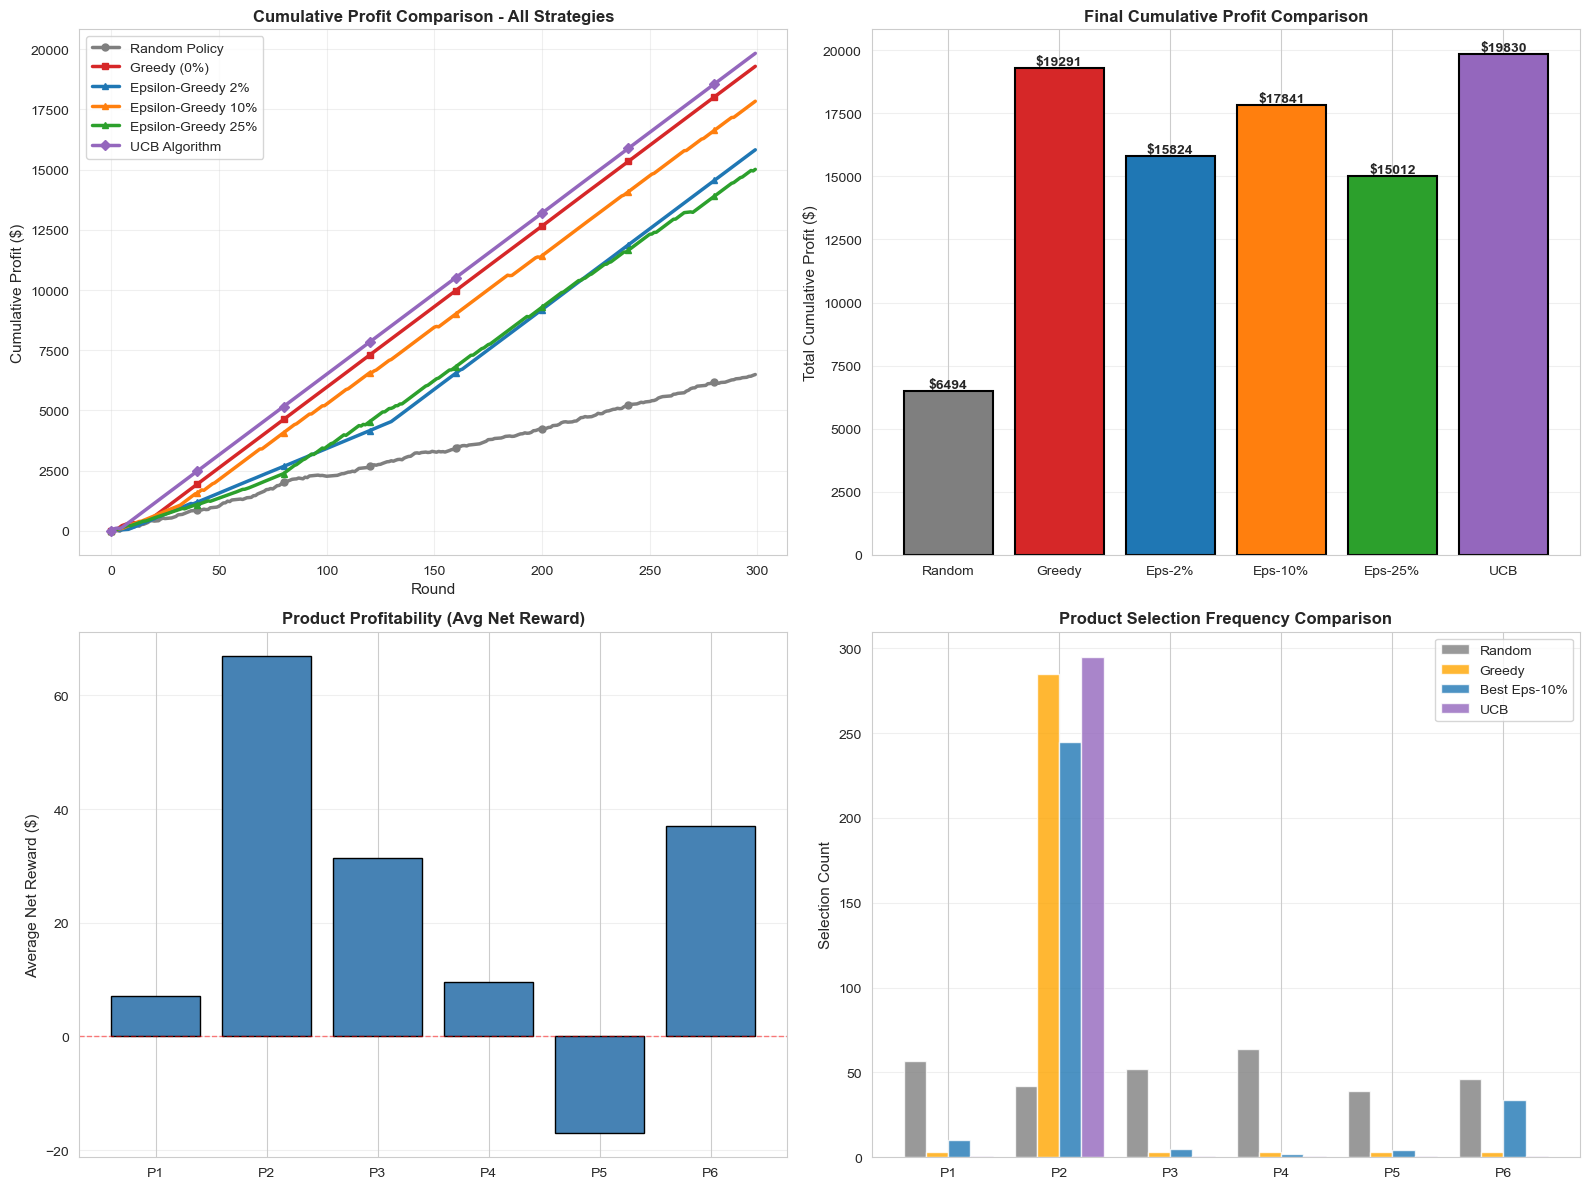


────────────────────────────────────────────────────────────────────────────────

✓ FINDINGS:

1. BEST OVERALL STRATEGY: UCB with $19829.71 cumulative profit

2. PROFIT IMPROVEMENT (vs Random):
   Greedy: +197.0%
   Epsilon 2%: +143.7%
   Epsilon 10%: +174.7%
   Epsilon 25%: +131.2%
   UCB: +205.3%

3. UCB ALGORITHM PERFORMANCE:
   UCB vs Best Epsilon (10%): +11.1%
   UCB Profit: $19829.71
   UCB automatically adapts exploration based on uncertainty!

4. MOST PROFITABLE PRODUCT: Product 2 (avg reward: $66.99)

5. LEAST PROFITABLE PRODUCT: Product 5 (avg reward: $-17.06)

────────────────────────────────────────────────────────────────────────────────



In [22]:
print("="*80)
print("STRATEGY COMPARISON & CUMULATIVE PROFIT ANALYSIS")
print("="*80)

# Ensure best_eg_result is defined from Strategy 3
if 'best_eg_result' not in globals():
    best_eg_result = epsilon_results[best_epsilon]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: All strategies cumulative profit
ax = axes[0, 0]
ax.plot(cumulative_random, linewidth=2.5, label='Random Policy', marker='o', markevery=40, markersize=5, color='#7f7f7f')
ax.plot(cumulative_greedy, linewidth=2.5, label='Greedy (0%)', marker='s', markevery=40, markersize=5, color='#d62728')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for epsilon, color in zip(epsilon_values, colors):
    result = epsilon_results[epsilon]
    ax.plot(result['cumulative'], linewidth=2.5, label=f'Epsilon-Greedy {epsilon:.0%}', 
            marker='^', markevery=40, markersize=5, color=color)

# Add UCB to the plot
ax.plot(cumulative_ucb, linewidth=2.5, label='UCB Algorithm', marker='D', markevery=40, markersize=5, color='#9467bd')

ax.set_xlabel('Round', fontsize=11)
ax.set_ylabel('Cumulative Profit ($)', fontsize=11)
ax.set_title('Cumulative Profit Comparison - All Strategies', fontsize=12, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.grid(True, alpha=0.3)

# Plot 2: Final cumulative profit comparison (bar chart)
ax = axes[0, 1]
strategies = ['Random', 'Greedy'] + [f'Eps-{e:.0%}' for e in epsilon_values] + ['UCB']
profits = [cumulative_random[-1], cumulative_greedy[-1]] + [epsilon_results[e]['total_profit'] for e in epsilon_values] + [cumulative_ucb[-1]]
colors_bar = ['#7f7f7f', '#d62728', '#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd']

bars = ax.bar(strategies, profits, color=colors_bar, edgecolor='black', linewidth=1.5)
ax.set_ylabel('Total Cumulative Profit ($)', fontsize=11)
ax.set_title('Final Cumulative Profit Comparison', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

for bar, profit in zip(bars, profits):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'${profit:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 3: Product profitability (average net rewards)
ax = axes[1, 0]
product_means = [env.summary_df[env.summary_df['Product']==i]['Mean'].values[0] for i in range(1, 7)]
product_labels = [f'P{i}' for i in range(1, 7)]
bars = ax.bar(product_labels, product_means, color='steelblue', edgecolor='black')
ax.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('Average Net Reward ($)', fontsize=11)
ax.set_title('Product Profitability (Avg Net Reward)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Plot 4: Product selection frequency across strategies (Updated)
ax = axes[1, 1]
best_eg_counts = list(best_eg_result['counts'].values())
ucb_counts_list = [ucb_counts[i] for i in range(1, 7)]
x = np.arange(len(product_labels))
width = 0.2

ax.bar(x - 1.5*width, [random_products.count(i) for i in range(1, 7)], width, label='Random', color='gray', alpha=0.8)
ax.bar(x - 0.5*width, [greedy_products.count(i) for i in range(1, 7)], width, label='Greedy', color='orange', alpha=0.8)
ax.bar(x + 0.5*width, best_eg_counts, width, label=f'Best Eps-{best_epsilon:.0%}', color='#1f77b4', alpha=0.8)
ax.bar(x + 1.5*width, ucb_counts_list, width, label='UCB', color='#9467bd', alpha=0.8)

ax.set_ylabel('Selection Count', fontsize=11)
ax.set_title('Product Selection Frequency Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(product_labels)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary findings
print(f"\n{'─'*80}")
print("\n✓ FINDINGS:\n")

# Collect all strategies for comparison
all_strategies = [
    ('Random', cumulative_random[-1]),
    ('Greedy', cumulative_greedy[-1]),
    ('Epsilon 2%', epsilon_results[0.02]['total_profit']),
    ('Epsilon 10%', epsilon_results[0.10]['total_profit']),
    ('Epsilon 25%', epsilon_results[0.25]['total_profit']),
    ('UCB', cumulative_ucb[-1])
]

best_strategy = max(all_strategies, key=lambda x: x[1])
print(f"1. BEST OVERALL STRATEGY: {best_strategy[0]} with ${best_strategy[1]:.2f} cumulative profit")

print(f"\n2. PROFIT IMPROVEMENT (vs Random):")
random_baseline = cumulative_random[-1]
for name, profit in all_strategies[1:]:
    improvement = ((profit - random_baseline) / random_baseline) * 100
    print(f"   {name}: {improvement:+.1f}%")

print(f"\n3. UCB ALGORITHM PERFORMANCE:")
ucb_vs_best_eg = ((cumulative_ucb[-1] - epsilon_results[best_epsilon]['total_profit']) / epsilon_results[best_epsilon]['total_profit']) * 100
print(f"   UCB vs Best Epsilon ({best_epsilon:.0%}): {ucb_vs_best_eg:+.1f}%")
print(f"   UCB Profit: ${cumulative_ucb[-1]:.2f}")
print(f"   UCB automatically adapts exploration based on uncertainty!")

print(f"\n4. MOST PROFITABLE PRODUCT: Product {env.best_product} (avg reward: ${env.best_mean:.2f})")
print(f"\n5. LEAST PROFITABLE PRODUCT: Product {env.worst_product} (avg reward: ${env.worst_mean:.2f})")

print(f"\n{'─'*80}\n")


FINAL ANALYSIS: 

WHICH STRATEGY WINS AND WHY?

WINNER: UCB ALGORITHM
  • Cumulative profit: $19,829.71
  • Improvement vs Random: +205.3%
  • Improvement vs Greedy: +2.8%

WHY UCB WINS:

1. INTELLIGENT EXPLORATION
   • UCB only tests uncertain products (those tried few times)
   • Products with bad estimates get abandoned: [1, 3, 4, 5, 6]
   • Best product (2) gets 295 selections out of 300

2. AVOIDS PREMATURE LOCK-IN
   • Unlike Greedy, UCB maintains exploration bonus
   • Would catch a better product if one existed
   • Greedy wasted ~18 rounds in initial exploration then locked in

3. EFFICIENCY VS EXPLORATION
   • Random: Wastes resources on all products equally
   • Epsilon 2%: Too little exploration, might miss good products
   • Epsilon 10%: Better but still explores low-value products
   • Epsilon 25%: Too much exploration (wastes 75 rounds)
   • UCB: Mathematically optimal - explores based on uncertainty

4. PROFIT PER ROUND
   • UCB avg/round: $66.10
   • Best Epsilon avg/round: $59.47
   • Random avg/round: $21.65

────────────────────────────────────────────────────────────────────────────────

Identify the most profitable product across all strategies?

PRODUCT 2 is the MOST PROFITABLE

  Average Net Reward: $66.99

